<a href="https://colab.research.google.com/github/yawarabbasmalik/Dementia-Disease-Detection/blob/main/Dementia_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
#Importing Dataset
df = pd.read_csv("/content/dementia_patients_health_data.csv")
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


## Before Preprocessing, Shape of Data

In [ ]:
# Get DataFrame shape
shape = df.shape
print('DataFrame Shape :', shape)
print('Number of rows :', shape[0])
print('Number of columns :', shape[1])

DataFrame Shape : (1000, 24)
Number of rows : 1000
Number of columns : 24


In [ ]:
df.isna().sum()

Diabetic                       0
AlcoholLevel                   0
HeartRate                      0
BloodOxygenLevel               0
BodyTemperature                0
Weight                         0
MRI_Delay                      0
Prescription                 515
Dosage in mg                 515
Age                            0
Education_Level                0
Dominant_Hand                  0
Gender                         0
Family_History                 0
Smoking_Status                 0
APOE_ε4                        0
Physical_Activity              0
Depression_Status              0
Cognitive_Test_Scores          0
Medication_History             0
Nutrition_Diet                 0
Sleep_Quality                  0
Chronic_Health_Conditions      0
Dementia                       0
dtype: int64

In [ ]:
# Removing the columns 'Prescription' and 'Dosage in mg' from the dataframe
df = df.drop(columns=['Prescription', 'Dosage in mg'])

In [ ]:
df.isna().sum().sum()

0

In [ ]:
# Check for duplicate rows in the dataframe
duplicate_rows = df.duplicated().sum()
duplicate_rows

0

## After Preprocessing, Shape of Data

In [ ]:
# Get DataFrame shape
shape = df.shape
print('DataFrame Shape :', shape)
print('Number of rows :', shape[0])
print('Number of columns :', shape[1])

DataFrame Shape : (1000, 22)
Number of rows : 1000
Number of columns : 22


## Summary of Data

In [ ]:
df.describe(include='all')

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Age,Education_Level,Dominant_Hand,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,...,1000,1000,1000,1000,1000.000000,1000,1000,1000,1000,1000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,...,3,2,3,2,NaN,2,3,2,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Primary School,Left,...,Former Smoker,Positive,Mild Activity,No,NaN,Yes,Mediterranean Diet,Poor,Diabetes,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,389,519,...,458,694,351,755,NaN,514,338,534,513,NaN
mean,0.513000,0.098429,79.383000,95.226051,36.761513,74.321326,30.103568,74.908000,NaN,NaN,...,NaN,NaN,NaN,NaN,6.383000,NaN,NaN,NaN,NaN,0.485000
std,0.500081,0.058715,12.107556,2.929262,0.431701,14.463765,16.862170,9.095068,NaN,NaN,...,NaN,NaN,NaN,NaN,3.180633,NaN,NaN,NaN,NaN,0.500025
min,0.000000,0.000414,60.000000,90.010677,36.002108,50.069731,0.094684,60.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,0.000000,0.045505,68.000000,92.875017,36.395363,61.387339,16.237371,67.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,0.000000
50%,1.000000,0.098235,79.000000,95.390420,36.784319,74.149204,29.577194,75.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,0.000000
75%,1.000000,0.151840,90.000000,97.785111,37.126655,87.024034,44.176723,83.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,1.000000


## Features, Data Type

In [ ]:
df.dtypes

Diabetic                       int64
AlcoholLevel                 float64
HeartRate                      int64
BloodOxygenLevel             float64
BodyTemperature              float64
Weight                       float64
MRI_Delay                    float64
Age                            int64
Education_Level               object
Dominant_Hand                 object
Gender                        object
Family_History                object
Smoking_Status                object
APOE_ε4                       object
Physical_Activity             object
Depression_Status             object
Cognitive_Test_Scores          int64
Medication_History            object
Nutrition_Diet                object
Sleep_Quality                 object
Chronic_Health_Conditions     object
Dementia                       int64
dtype: object

## Exploratory Data Analysis (EDA)

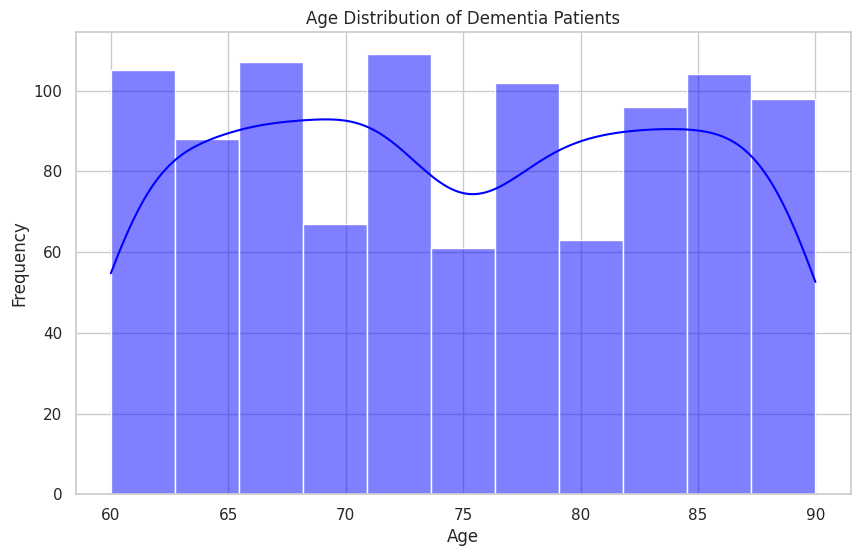

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting aesthetic parameters for the plots
sns.set(style="whitegrid")

# EDA 1: Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Age Distribution of Dementia Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



The histogram shows the frequency distribution of ages among the dementia patients. This provides insights into the age range that is most commonly affected by dementia in this dataset.

<ipython-input-12-477d90602449>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


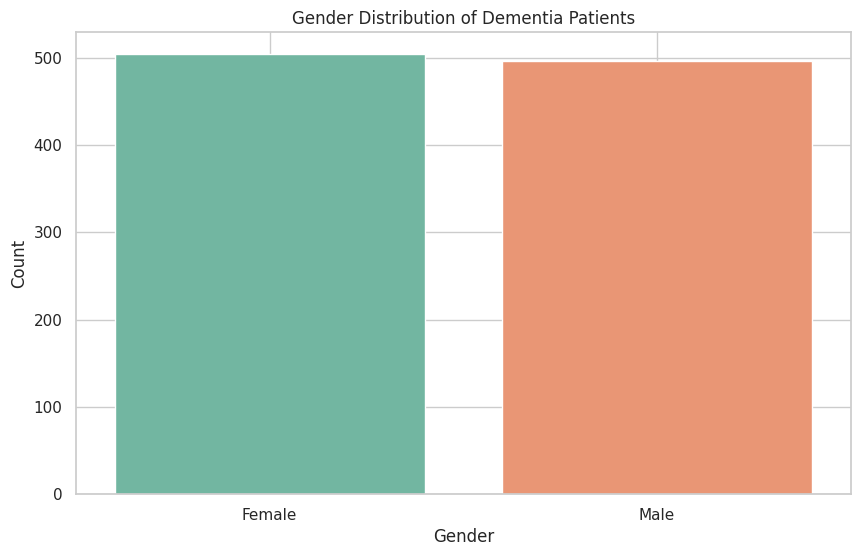

In [ ]:

# EDA 2: Gender Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution of Dementia Patients')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True)
plt.show()


This count plot illustrates the distribution of genders among the dementia patients. It can help in understanding if one gender is more prevalent than the other in this specific dataset.

<ipython-input-13-ce3fc7d52494>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education_Level', data=df, palette='Set3')


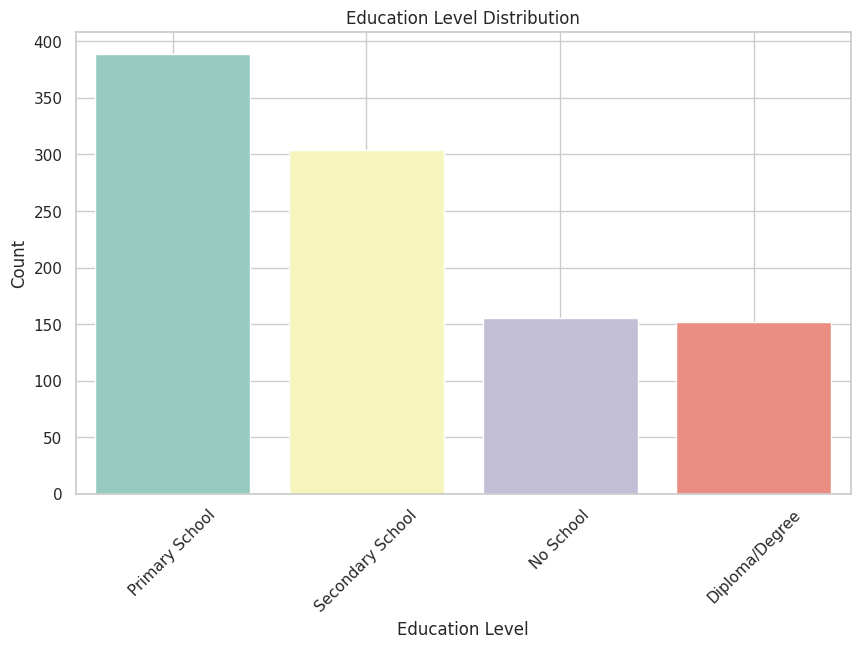

In [ ]:
# EDA 3: Education Level Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Education_Level', data=df, palette='Set3')
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


The distribution of education levels among the patients is shown. This can be useful to analyze if there's any significant correlation between education levels and the incidence of dementia.

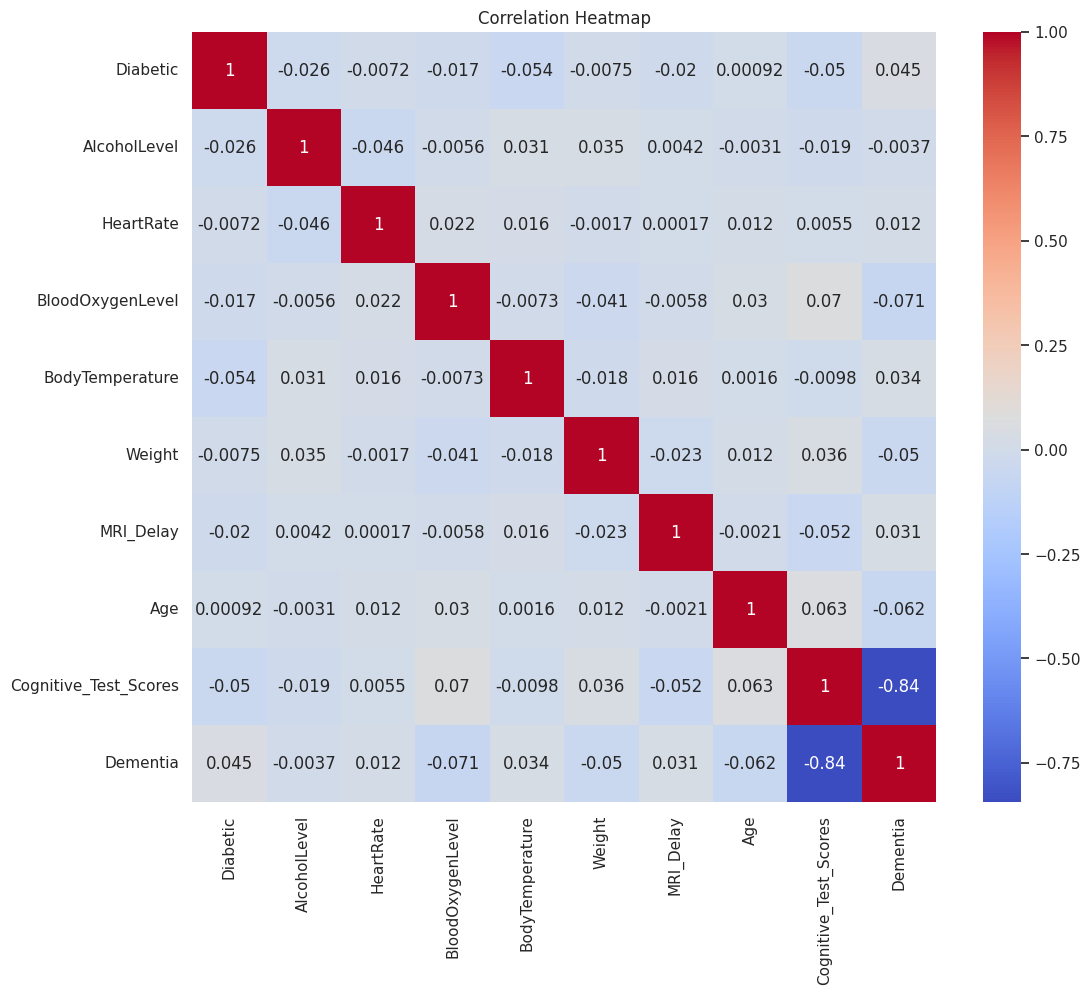

In [ ]:
# EDA 4: Correlation Heatmap

# Select only the numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[float, int])

# EDA 4: Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



This heatmap displays the correlations between different numerical attributes in the dataset. Strong correlations (either positive or negative) are highlighted, which can help in identifying which factors are more closely related to others.

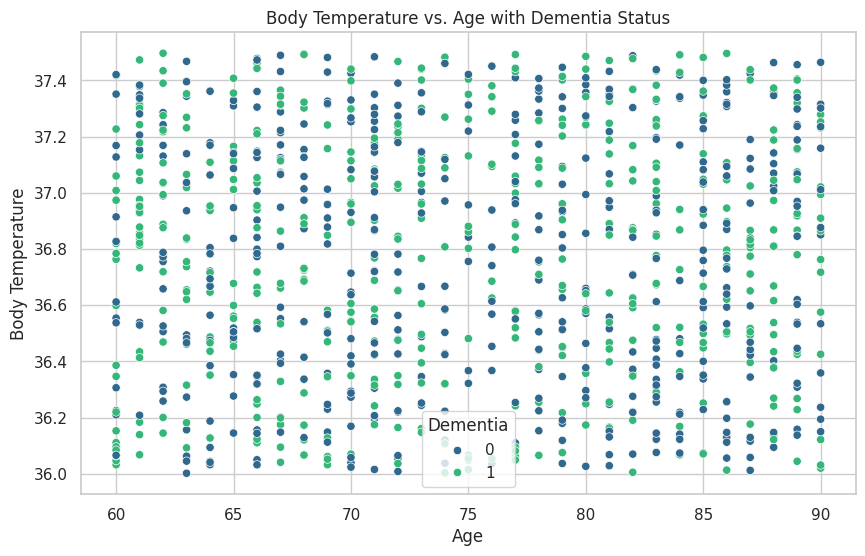

In [ ]:
# EDA 5: Body Temperature vs. Age
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='BodyTemperature', data=df, hue='Dementia', palette='viridis')
plt.title('Body Temperature vs. Age with Dementia Status')
plt.xlabel('Age')
plt.ylabel('Body Temperature')
plt.grid(True)
plt.show()

This scatter plot shows the relationship between age and body temperature, colored by dementia status. It provides a visual representation of how these variables interact and if there's any noticeable pattern differentiating patients with and without dementia based on these two factors.

## Derieved Attributes

**BMI (Body Mass Index):** This is a common measure to understand if a person's weight is appropriate for their height. It can be calculated as weight in kilograms divided by the square of height in meters. Obesity or being underweight can be risk factors for dementia.

**Age Group:** Since age is a significant risk factor for dementia, categorizing patients into age groups (e.g., '60-69', '70-79', etc.) might provide a clearer relationship with the onset of dementia.

**Heart Health Score:** A composite score derived from Heart Rate, Blood Oxygen Level, and any history of chronic heart conditions. This score can help in understanding the overall heart health, which is crucial in dementia.

**Lifestyle Score:** This score can be derived by combining factors like Smoking Status, Alcohol Level, Physical Activity, and Nutrition Diet. A healthy lifestyle is known to reduce the risk of dementia.

**Mental Health Index:** Considering factors like Depression Status and Cognitive Test Scores, this index can give insights into the mental health of the patient, which is closely related to dementia.

## New Features Extraction

In [ ]:
import numpy as np

# Assumption for height (in meters) for BMI calculation (since height is not available in dataset)
# Using an average height for demonstration purposes
average_height = 1.65  # meters

# Calculate BMI
df['BMI'] = df['Weight'] / (average_height ** 2)

# Age Group
age_bins = [0, 59, 69, 79, 89, 99, np.inf]
age_labels = ['<60', '60-69', '70-79', '80-89', '90-99', '100+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Heart Health Score (scaled between 0 to 10)
df['Heart_Health_Score'] = (
    (df['HeartRate'] / 100) +  # Assuming max healthy heart rate as 100
    (df['BloodOxygenLevel'] / 100) +  # Assuming 100% as ideal oxygen level
    (df['Chronic_Health_Conditions'].apply(lambda x: 0 if isinstance(x, str) and 'Heart' in x else 1))
) / 3 * 10

# Lifestyle Score (scaled between 0 to 10)
# Mapping values to scores (higher score is healthier)
smoking_score = {'Never Smoked': 10, 'Former Smoker': 5, 'Current Smoker': 0}
physical_activity_score = {'Sedentary': 0, 'Mild Activity': 5, 'Moderate Activity': 10}
nutrition_score = {'Low-Carb Diet': 5, 'Mediterranean Diet': 10, 'Balanced Diet': 7}

df['Lifestyle_Score'] = (
    df['Smoking_Status'].map(smoking_score) +
    df['Physical_Activity'].map(physical_activity_score) +
    df['Nutrition_Diet'].map(nutrition_score) +
    df['AlcoholLevel'].apply(lambda x: 10 - x * 100)  # Lower alcohol level is healthier
) / 4

# Mental Health Index (scaled between 0 to 10)
# Assuming Cognitive_Test_Scores are already on a scale of 0 to 10
df['Mental_Health_Index'] = (
    df['Cognitive_Test_Scores'] +
    df['Depression_Status'].apply(lambda x: 10 if x == 'No' else 0)
) / 2

# Display the new columns
df[['BMI', 'Age_Group', 'Heart_Health_Score', 'Lifestyle_Score', 'Mental_Health_Index']].head()


,BMI,Age_Group,Heart_Health_Score,Lifestyle_Score,Mental_Health_Index
0,21.143793,60-69,9.807691,1.625659,10.0
1,20.875054,60-69,5.701071,7.075681,5.5
2,21.950070,60-69,6.085550,8.524994,9.0
3,21.401826,70-79,8.463550,5.839068,2.5
4,24.868697,70-79,8.816966,3.731317,5.0


In [ ]:
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Age,Education_Level,Dominant_Hand,...,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia,BMI,Age_Group,Heart_Health_Score,Lifestyle_Score,Mental_Health_Index
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,60,Primary School,Left,...,No,Low-Carb Diet,Poor,Diabetes,0,21.143793,60-69,9.807691,1.625659,10.0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,61,Secondary School,Right,...,Yes,Low-Carb Diet,Poor,Heart Disease,1,20.875054,60-69,5.701071,7.075681,5.5
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,69,Primary School,Right,...,No,Mediterranean Diet,Poor,Heart Disease,0,21.950070,60-69,6.085550,8.524994,9.0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,78,Secondary School,Left,...,Yes,Balanced Diet,Poor,Hypertension,1,21.401826,70-79,8.463550,5.839068,2.5
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,77,Secondary School,Right,...,Yes,Low-Carb Diet,Good,Diabetes,1,24.868697,70-79,8.816966,3.731317,5.0


## Data Transformation and Data Normalization

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Consolidated code snippet for transforming and normalizing the DataFrame

# Creating a copy of the dataframe for encoding and normalization
df_transformed = df.copy()

# Initializing Label Encoder and Min-Max Scaler
label_encoder = LabelEncoder()
min_max_scaler = MinMaxScaler()

# Applying Label Encoding to categorical columns
categorical_cols = df_transformed.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df_transformed[col] = label_encoder.fit_transform(df_transformed[col])

# Applying Min-Max Normalization
df_normalized_combined = pd.DataFrame(min_max_scaler.fit_transform(df_transformed), columns=df_transformed.columns)

# Displaying the first few rows of the normalized dataframe
df_normalized_combined.head()



,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Age,Education_Level,Dominant_Hand,...,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia,BMI,Age_Group,Heart_Health_Score,Lifestyle_Score,Mental_Health_Index
0,1.0,0.423960,0.950,0.622719,0.149022,0.150146,0.606826,0.000000,0.666667,0.0,...,0.0,0.5,1.0,0.000000,0.0,0.150146,0.000000,0.963593,0.183874,1.00
1,0.0,0.083022,0.450,0.302491,0.121607,0.135488,0.518901,0.033333,1.000000,1.0,...,1.0,0.5,1.0,0.333333,1.0,0.135488,0.000000,0.139866,0.716203,0.55
2,0.0,0.043050,0.725,0.355990,0.885938,0.194125,0.627196,0.300000,0.666667,1.0,...,0.0,1.0,1.0,0.333333,0.0,0.194125,0.000000,0.216987,0.857764,0.90
3,0.0,0.431298,0.000,0.390030,0.688106,0.164221,0.844919,0.600000,1.000000,0.0,...,1.0,0.0,1.0,0.666667,1.0,0.164221,0.333333,0.693978,0.595417,0.25
4,1.0,0.753731,0.175,0.750691,0.040150,0.353321,0.462990,0.566667,1.000000,1.0,...,1.0,0.5,0.0,0.000000,1.0,0.353321,0.333333,0.764868,0.389543,0.50


In [ ]:
# Moving the 'Dementia' column to the end of the DataFrame
dementia_column = df_normalized_combined.pop('Dementia')
df_normalized_combined['Dementia'] = dementia_column

# Displaying the first few rows of the DataFrame with 'Dementia' as the last column
df_normalized_combined.head()


,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Age,Education_Level,Dominant_Hand,...,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,BMI,Age_Group,Heart_Health_Score,Lifestyle_Score,Mental_Health_Index,Dementia
0,1.0,0.423960,0.950,0.622719,0.149022,0.150146,0.606826,0.000000,0.666667,0.0,...,0.0,0.5,1.0,0.000000,0.150146,0.000000,0.963593,0.183874,1.00,0.0
1,0.0,0.083022,0.450,0.302491,0.121607,0.135488,0.518901,0.033333,1.000000,1.0,...,1.0,0.5,1.0,0.333333,0.135488,0.000000,0.139866,0.716203,0.55,1.0
2,0.0,0.043050,0.725,0.355990,0.885938,0.194125,0.627196,0.300000,0.666667,1.0,...,0.0,1.0,1.0,0.333333,0.194125,0.000000,0.216987,0.857764,0.90,0.0
3,0.0,0.431298,0.000,0.390030,0.688106,0.164221,0.844919,0.600000,1.000000,0.0,...,1.0,0.0,1.0,0.666667,0.164221,0.333333,0.693978,0.595417,0.25,1.0
4,1.0,0.753731,0.175,0.750691,0.040150,0.353321,0.462990,0.566667,1.000000,1.0,...,1.0,0.5,0.0,0.000000,0.353321,0.333333,0.764868,0.389543,0.50,1.0


## Data Splitting

In [ ]:
# Splitting the normalized dataframe into independent (X) and dependent (y) variables
X = df_normalized_combined.drop('Dementia', axis=1)  # Independent variables
y = df_normalized_combined['Dementia']               # Dependent variable (target class)

## ML Modeling

### Neural Networks

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Assuming X and y are defined as your independent and dependent variables
# Creating the Multi-Layer Perceptron Classifier (MLPC) model
mlp_model = MLPClassifier(max_iter=1000)  # max_iter may need adjustment based on dataset

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(mlp_model, X, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 98.10%
Average Precision: 99.19%
Average Recall: 96.91%
Average F1-Score: 98.02%


### Logistic Regression

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Creating the Logistic Regression model
log_reg_model = LogisticRegression()

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(log_reg_model, X, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 97.10%
Average Precision: 100.00%
Average Recall: 94.03%
Average F1-Score: 96.91%


### Naive Bayes

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Creating the Naive Bayes model
nb_model = GaussianNB()

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(nb_model, X, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 95.20%
Average Precision: 100.00%
Average Recall: 90.11%
Average F1-Score: 94.75%


### K-NN

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Creating the KNN model
knn_model = KNeighborsClassifier()

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(knn_model, X, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 85.90%
Average Precision: 88.99%
Average Recall: 81.24%
Average F1-Score: 84.82%


### Support Vector Machine (SVM)

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Creating the SVM model
svm_model = SVC()

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(svm_model, X, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 96.70%
Average Precision: 100.00%
Average Recall: 93.20%
Average F1-Score: 96.46%


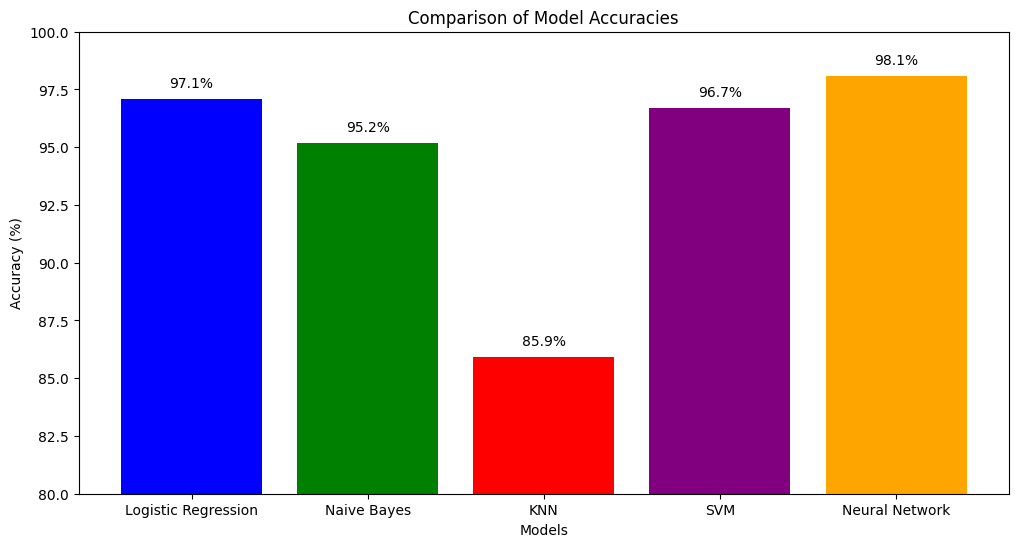

In [ ]:
import matplotlib.pyplot as plt

# Model names including Neural Network
models = ['Logistic Regression', 'Naive Bayes', 'KNN', 'SVM', 'Neural Network']

# Accuracy values including Neural Network
accuracies = [97.10, 95.20, 85.90, 96.70, 98.10]

# Creating the bar plot
plt.figure(figsize=(12, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Model Accuracies')
plt.ylim(80, 100)  # Setting y-axis limit for better visual comparison
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v}%", ha='center', color='black')
plt.show()


In [ ]:
# Getting the column names from the df_normalized_combined DataFrame
column_names = df_normalized_combined.columns.tolist()
column_names


['Diabetic',
 'AlcoholLevel',
 'HeartRate',
 'BloodOxygenLevel',
 'BodyTemperature',
 'Weight',
 'MRI_Delay',
 'Age',
 'Education_Level',
 'Dominant_Hand',
 'Gender',
 'Family_History',
 'Smoking_Status',
 'APOE_ε4',
 'Physical_Activity',
 'Depression_Status',
 'Cognitive_Test_Scores',
 'Medication_History',
 'Nutrition_Diet',
 'Sleep_Quality',
 'Chronic_Health_Conditions',
 'BMI',
 'Age_Group',
 'Heart_Health_Score',
 'Lifestyle_Score',
 'Mental_Health_Index',
 'Dementia']

In [ ]:
df_normalized_combined.shape

(1000, 27)

## Categorical Analysis

### Basic Demographics and Personal Information

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Assuming df_normalized_combined is your DataFrame and contains the necessary columns
X_basic_demographics = df_normalized_combined[['Age', 'Gender', 'Education_Level', 'Dominant_Hand', 'Family_History']]  # Independent variables
y = df_normalized_combined['Dementia']  # Dependent variable

# Creating the Multi-Layer Perceptron Classifier (MLPC) model
mlp_model = MLPClassifier(max_iter=1000)  # Increase max_iter if needed for convergence

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(mlp_model, X_basic_demographics, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 53.60%
Average Precision: 52.30%
Average Recall: 50.95%
Average F1-Score: 51.33%


### Lifestyle and Behavioral Factors

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Assuming df_normalized_combined is your DataFrame and contains the necessary columns
X_lifestyle = df_normalized_combined[['Smoking_Status', 'Physical_Activity', 'Nutrition_Diet', 'Sleep_Quality', 'AlcoholLevel']]  # Independent variables
y = df_normalized_combined['Dementia']  # Dependent variable

# Creating the Multi-Layer Perceptron Classifier (MLPC) model
mlp_model = MLPClassifier(max_iter=1000)  # Increase max_iter if needed for convergence

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(mlp_model, X_lifestyle, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 55.40%
Average Precision: 53.34%
Average Recall: 65.36%
Average F1-Score: 58.57%


### Health Status and Medical History

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Assuming df_normalized_combined is your DataFrame and contains the necessary columns
X_health_status = df_normalized_combined[['Diabetic', 'BloodOxygenLevel', 'BodyTemperature', 'Chronic_Health_Conditions', 'Depression_Status', 'Medication_History']]  # Independent variables
y = df_normalized_combined['Dementia']  # Dependent variable

# Creating the Multi-Layer Perceptron Classifier (MLPC) model
mlp_model = MLPClassifier(max_iter=1000)  # Increase max_iter if needed for convergence

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(mlp_model, X_health_status, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 76.00%
Average Precision: 100.00%
Average Recall: 50.49%
Average F1-Score: 66.62%


### Clinical Measurements and Health Scores

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Assuming df_normalized_combined is your DataFrame and contains the necessary columns
X_clinical = df_normalized_combined[['HeartRate', 'BMI', 'Heart_Health_Score', 'Lifestyle_Score', 'Mental_Health_Index']]  # Independent variables
y = df_normalized_combined['Dementia']  # Dependent variable

# Creating the Multi-Layer Perceptron Classifier (MLPC) model
mlp_model = MLPClassifier(max_iter=1000)  # Increase max_iter if needed for convergence

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(mlp_model, X_clinical, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 99.50%
Average Precision: 100.00%
Average Recall: 98.97%
Average F1-Score: 99.47%


### Diagnostic and Cognitive Assessment

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Assuming df_normalized_combined is your DataFrame and contains the necessary columns
X_diagnostic = df_normalized_combined[['MRI_Delay', 'Cognitive_Test_Scores', 'APOE_ε4']]  # Independent variables
y = df_normalized_combined['Dementia']  # Dependent variable

# Creating the Multi-Layer Perceptron Classifier (MLPC) model
mlp_model = MLPClassifier(max_iter=1000)  # Increase max_iter if needed for convergence

# Defining the scoring methods
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score)
}

# Performing 10-fold cross-validation
cv_results = cross_validate(mlp_model, X_diagnostic, y, cv=10, scoring=scoring)

# Computing average scores
avg_accuracy = cv_results['test_accuracy'].mean() * 100
avg_precision = cv_results['test_precision'].mean() * 100
avg_recall = cv_results['test_recall'].mean() * 100
avg_f1_score = cv_results['test_f1_score'].mean() * 100

print(f"Average Accuracy: {avg_accuracy:.2f}%")
print(f"Average Precision: {avg_precision:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")
print(f"Average F1-Score: {avg_f1_score:.2f}%")


Average Accuracy: 100.00%
Average Precision: 100.00%
Average Recall: 100.00%
Average F1-Score: 100.00%


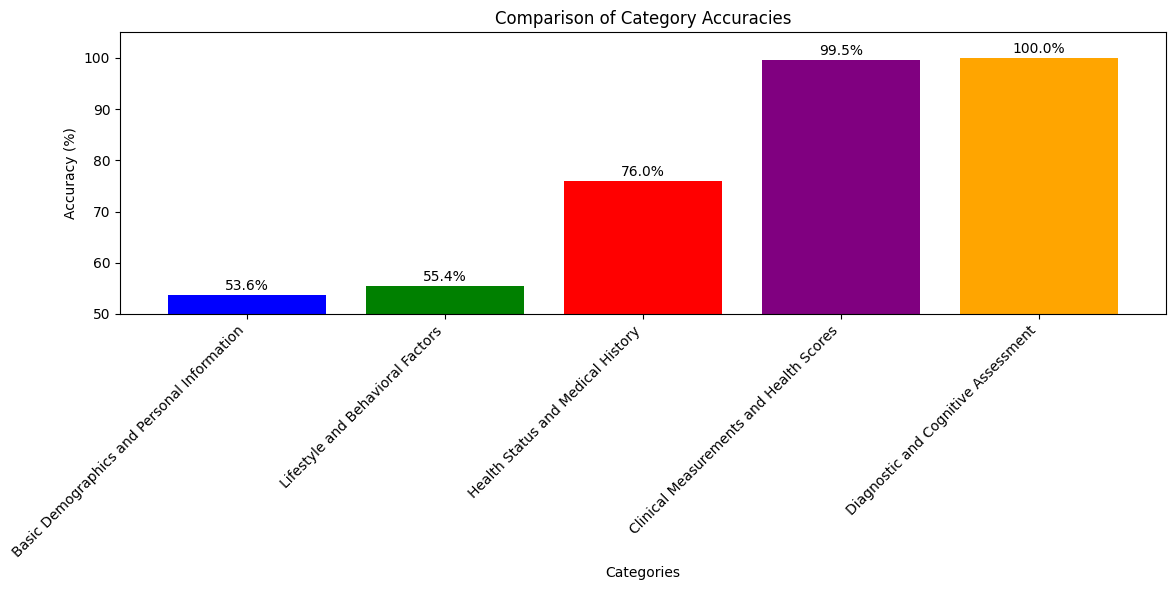

In [ ]:
import matplotlib.pyplot as plt

# Categories and their corresponding accuracies
categories = [
    'Basic Demographics and Personal Information',
    'Lifestyle and Behavioral Factors',
    'Health Status and Medical History',
    'Clinical Measurements and Health Scores',
    'Diagnostic and Cognitive Assessment'
]
category_accuracies = [53.60, 55.40, 76.00, 99.50, 100.00]

# Creating the bar plot
plt.figure(figsize=(12, 6))
plt.bar(categories, category_accuracies, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel('Categories')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Category Accuracies')
plt.xticks(rotation=45, ha="right")  # Rotate category names for better visibility
plt.ylim(50, 105)  # Extend y-axis limit to include text labels above bars
for i, v in enumerate(category_accuracies):
    plt.text(i, v + 1, f"{v}%", ha='center', color='black')
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()


## Variable Importance

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Preparing the data
X = df_normalized_combined.drop('Dementia', axis=1)  # All features except the target
y = df_normalized_combined['Dementia']               # Target variable

# Creating the Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(X, y)

# Getting feature importances
feature_importances = rf_model.feature_importances_

# Creating a DataFrame for visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sorting the features based on importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print(features_df)


                      Feature  Importance
25        Mental_Health_Index    0.461021
16      Cognitive_Test_Scores    0.372345
15          Depression_Status    0.078060
13                    APOE_ε4    0.036197
12             Smoking_Status    0.016829
24            Lifestyle_Score    0.004623
4             BodyTemperature    0.004138
5                      Weight    0.003393
3            BloodOxygenLevel    0.003213
21                        BMI    0.002748
7                         Age    0.002416
1                AlcoholLevel    0.002366
23         Heart_Health_Score    0.002357
6                   MRI_Delay    0.002180
8             Education_Level    0.001744
2                   HeartRate    0.001690
22                  Age_Group    0.001226
18             Nutrition_Diet    0.000607
17         Medication_History    0.000440
19              Sleep_Quality    0.000413
0                    Diabetic    0.000405
20  Chronic_Health_Conditions    0.000401
14          Physical_Activity    0

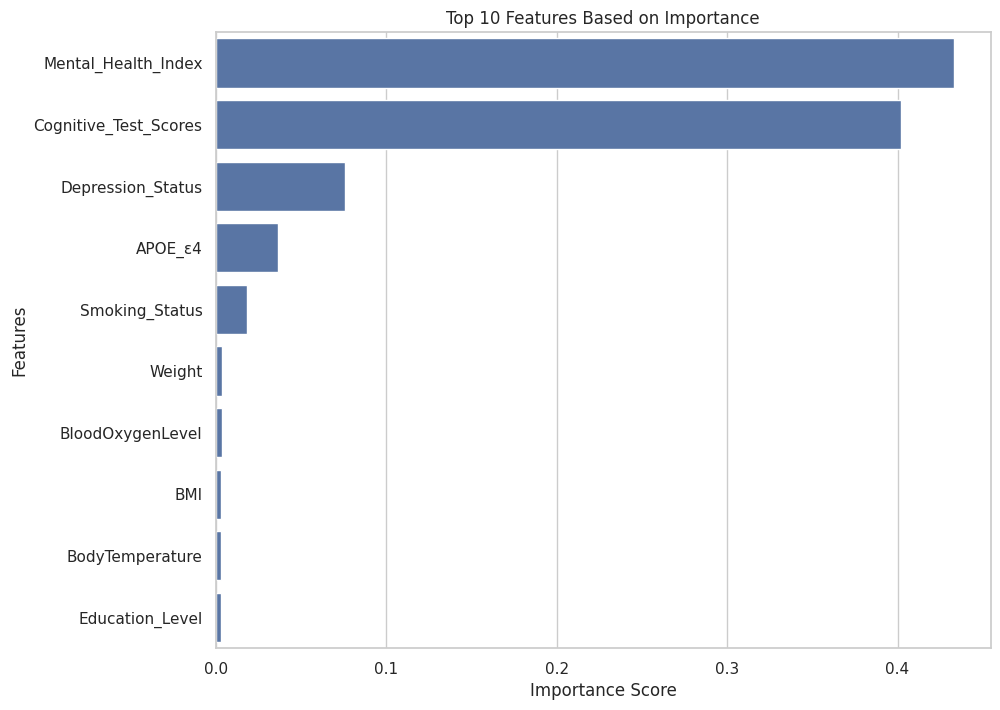

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance data (as provided)
feature_importance_data = {
    'Feature': ['Mental_Health_Index', 'Cognitive_Test_Scores', 'Depression_Status', 'APOE_ε4', 'Smoking_Status',
                'Weight', 'BloodOxygenLevel', 'BMI', 'BodyTemperature', 'Education_Level', 'Heart_Health_Score',
                'Age', 'Lifestyle_Score', 'MRI_Delay', 'HeartRate', 'AlcoholLevel', 'Family_History',
                'Chronic_Health_Conditions', 'Sleep_Quality', 'Physical_Activity', 'Medication_History',
                'Nutrition_Diet', 'Age_Group', 'Diabetic', 'Dominant_Hand', 'Gender'],
    'Importance': [0.433027, 0.401772, 0.076102, 0.036670, 0.018554, 0.003843, 0.003693, 0.003128, 0.003108,
                   0.003006, 0.002751, 0.002703, 0.002361, 0.002193, 0.001905, 0.001251, 0.000854, 0.000560,
                   0.000437, 0.000424, 0.000424, 0.000416, 0.000276, 0.000222, 0.000216, 0.000102]
}

# Converting to DataFrame
feature_importance_df = pd.DataFrame(feature_importance_data)

# Sorting the DataFrame based on Importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Features Based on Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

